In [1]:
import h5py
import quimb as qu
import quimb.tensor as qtn
import numpy as np

### Read data

In [2]:
with h5py.File("save_results/arrays.h5", "r") as f:
    keys = sorted(f.keys(), key=lambda x: int(x.split("_")[1]))
    print(keys)
    M1 = [f[key][:] for key in keys]

['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9', 'arr_10']


In [3]:
for i in range(len(M1)):
    print(M1[i].shape)

(1, 2, 2, 2)
(2, 2, 2, 4)
(4, 2, 2, 8)
(8, 2, 2, 14)
(14, 2, 2, 18)
(18, 2, 2, 14)
(14, 2, 2, 8)
(8, 2, 2, 4)
(4, 2, 2, 2)
(2, 2, 2, 1)


In [ ]:
def array_to_lpdo(M1, tags):
    # convert input list of arrays to LPDO

    L = len(M1)

    inds = ('k0','b0','l0')
    first_tensor = M1[0][0,:,:,:]
    last_tensor = M1[-1][:,:,:,0]
    lpdo_1 = qtn.Tensor(data=first_tensor, inds=inds, tags=tags)

    for i in range(1, L):
        if i == L-1:
            inds = (f'l{i-1}', f'k{i}', f'b{i}')
            current_tensor = qtn.Tensor(data=last_tensor, inds=inds, tags=tags)
        else:
            inds = (f'l{i-1}', f'k{i}', f'b{i}', f'l{i}')
            current_tensor = qtn.Tensor(data=M1[i], inds=inds, tags=tags)

        lpdo_1 = lpdo_1 & current_tensor

    return lpdo_1

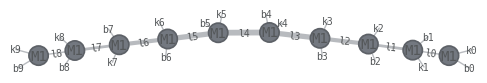

In [21]:
tags = ('M1',)
lpdo_1 = array_to_lpdo(M1, tags)
lpdo_1.draw(show_inds='all')

In [23]:
lpdo_1

TensorNetwork(tensors=10, indices=29)

### Circuit

In [59]:
def staircase(circ, reverse=False,gate_round=None):

    regs = range(0, circ.N - 1)
    if reverse:
        regs = reversed(regs)
    
    for i in regs:
        u = qtn.array_ops.PArray(
            params=qu.randn((4, 4)),   # trainable parameters, random init
            fn=qtn.decomp.isometrize, # constraint function
            # shape=(2, 2, 2, 2)         # physical legs: two qubits
        )
        circ.apply_gate(
            u, i, i+1, gate_round=gate_round, parametrize=True
        )


def ansatz_circuit(n, depth, **kwargs):
    """Construct a circuit of single qubit and entangling layers.
    """
    circ = qtn.Circuit(n, **kwargs)

    for r in range(depth):
        staircase(
            circ, gate_round=r, reverse=r % 2 == 0)

    return circ

In [60]:
n = 10
depth = 2

circ = ansatz_circuit(n, depth)
circ

ValueError: You cannot specify ``parametrize`` for raw gate, supply a ``PArray`` instead.

In [18]:
V = circ.uni

c:\Users\yliu\anaconda3\Lib\site-packages\quimb\tensor\circuit.py:2587: FutureWarning: In future the tensor network returned by ``circ.uni`` will not be transposed as it is currently, to match the expectation from ``U = circ.uni.to_dense()`` behaving like ``U @ psi``. You can retain this behaviour with ``circ.get_uni(transposed=True)``.
  warnings.warn(


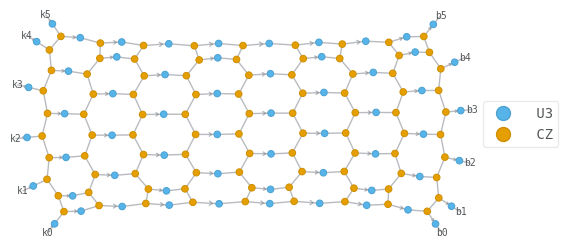

In [19]:
V.draw(color=['U3', gate2], show_inds=True)

In [22]:
V

TensorNetworkGenOperator(tensors=150, indices=201)

In [ ]:
def loss(V, U):
    return 1 - abs((V.H & U).contract(all, optimize='auto-hq')) / 2**n

# check our current unitary 'infidelity':
loss(V, U)